# Performance Metrics Dashboard

The README proposes five performance metrics and two adoption metrics to
evaluate CERM, but the app itself has no backend or event log, so none of
them were ever actually computed -- they were a plan, not a result. This
notebook computes what it honestly can from a **discrete-event simulation**:
requests and helpers arrive over a simulated 72-hour window, and every
matching decision is made by the real `score_tracts()` logic (ported from
`index.html`, same as
[`matching_model_evaluation.ipynb`](matching_model_evaluation.ipynb)) rather
than a shortcut.

Two of the seven proposed metrics turn out to be **not computable** from
anything in this repo -- Evacuation Efficiency needs real before/after
timing data, and the adoption metrics need production usage telemetry.
Section 6 explains why rather than inventing numbers for them.


In [1]:
import json
import math
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

random.seed(7)
np.random.seed(7)
plt.rcParams["figure.dpi"] = 110


## 1. Load data and replicate the live matching engine

Identical to Section 1 of the companion notebook -- ported line-for-line
from `index.html` so scores here match what the browser would compute.


In [2]:
with open("../data/wildfire_community_tracts.geojson") as f:
    geo = json.load(f)

def crude_centroid(geometry):
    if geometry["type"] == "MultiPolygon":
        coords = geometry["coordinates"][0][0]
    else:
        coords = geometry["coordinates"][0]
    lats = [pt[1] for pt in coords]
    lons = [pt[0] for pt in coords]
    return sum(lats) / len(lats), sum(lons) / len(lons)

tracts = []
for feat in geo["features"]:
    p = feat["properties"]
    clat, clon = crude_centroid(feat["geometry"])
    tracts.append({
        "geoid": p["GEOID"], "county": p["county_name"],
        "flag_elderly": p["flag_high_elderly"], "flag_disability": p["flag_high_disability"],
        "flag_novehicle": p["flag_low_vehicle_access"], "total_flags": p["total_flags"],
        "clat": clat, "clon": clon,
    })
tracts = pd.DataFrame(tracts)

requests_df = pd.read_csv("../data/requests.csv", dtype={"geoid": str})

FIRE_TRACTS = {"Butte": "06007000700", "Shasta": "06089010806", "Riverside": "06065040402"}
FIRE_GEOIDS = set(FIRE_TRACTS.values())
TYPE_TO_SERVICE_TAG = {
    "Transportation": "transportation", "Medical": "medical", "Food & Water": "food_distribution",
    "Supplies": "volunteer_labor", "Mobility Help": "mobility_assistance", "Childcare": "childcare",
    "General": "general", "New Request": "general",
}
SERVICE_TAGS = ["transportation", "mobility_assistance", "heavy_lifting", "medical",
                "food_distribution", "volunteer_labor", "childcare"]
BENEFICIARY_TAGS = ["elderly", "disability", "no_vehicle", "families", "children", "general"]

def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    dlat, dlon = math.radians(lat2 - lat1), math.radians(lon2 - lon1)
    a = math.sin(dlat / 2) ** 2 + math.cos(math.radians(lat1)) * math.cos(math.radians(lat2)) * math.sin(dlon / 2) ** 2
    return R * 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))

print(f"{len(tracts)} tracts, {len(requests_df)} requests loaded")


951 tracts, 200 requests loaded


## 2. Simulate arrivals over time

`requests.csv` and the app itself have no timestamps -- every request is
just "currently open." To measure anything time-based (Demand Coverage,
etc.) we need arrival times, so we assign each of the 200 real requests a
simulated arrival time drawn uniformly across a 72-hour window (a 3-day
acute response period), and simulate helpers arriving as a Poisson process
at a rate calibrated to produce a realistic partial-coverage scenario
(not a trivial 0% or 100%). **This is the one place synthetic timing is
injected** -- the requests, tracts, flags, and matching logic downstream of
it are all real.


In [3]:
T_MAX = 72.0  # hours

sim_requests = requests_df.copy()
sim_requests["arrival_h"] = np.random.uniform(0, T_MAX, len(sim_requests))
sim_requests["resolved_h"] = np.nan
sim_requests["service_tag_list"] = sim_requests["service_tags"].apply(
    lambda s: [t.strip() for t in str(s).replace(";", "|").split("|") if t.strip()]
)

def unresolved_at(t, county=None):
    mask = (sim_requests["arrival_h"] <= t) & sim_requests["resolved_h"].isna()
    if county is not None:
        mask &= sim_requests["county"] == county
    return sim_requests[mask]


def score_tracts_live(county, ben_tags, svc_tags, provider_latlon, t):
    """Same scoring logic as score_tracts() in the companion notebook, but
    reading the *live* (time-dependent) set of unresolved requests instead
    of a static snapshot."""
    candidates = tracts[(tracts["county"] == county) & (~tracts["geoid"].isin(FIRE_GEOIDS))]
    live_reqs = unresolved_at(t, county)
    hands_by_tract = live_reqs.groupby("geoid").size().to_dict()
    max_hands = max(hands_by_tract.values(), default=1)
    max_hands = max(max_hands, 1)

    ben_set, svc_set = set(ben_tags), set(svc_tags)
    rows = []
    for row in candidates.itertuples():
        h = hands_by_tract.get(row.geoid, 0)
        if row.total_flags <= 0 and h <= 0:
            continue
        v_fit = 0.0
        if "elderly" in ben_set or "general" in ben_set:
            v_fit += row.flag_elderly
        if "disability" in ben_set or "general" in ben_set:
            v_fit += row.flag_disability
        if "no_vehicle" in ben_set or "transportation" in svc_set or "general" in ben_set:
            v_fit += row.flag_novehicle
        v_fit /= 3
        r_vol = h / max_hands

        req_match = 0.0
        tract_reqs = live_reqs[live_reqs["geoid"] == row.geoid]
        if svc_tags and h > 0:
            matches = 0
            for _, req in tract_reqs.iterrows():
                primary = TYPE_TO_SERVICE_TAG.get(req["request_type"])
                if primary and primary in svc_set:
                    matches += 1
                    continue
                if any(tg in svc_set for tg in req["service_tag_list"]):
                    matches += 1
            req_match = matches / len(tract_reqs) if len(tract_reqs) else 0.0

        prox = 0.5
        if provider_latlon is not None:
            dist = haversine(provider_latlon[0], provider_latlon[1], row.clat, row.clon)
            prox = 1 / (1 + dist / 10)

        score = 0.25 * v_fit + 0.15 * r_vol + 0.25 * req_match + 0.35 * prox
        rows.append({"geoid": row.geoid, "v_fit": v_fit, "r_vol": r_vol, "req_match": req_match,
                      "prox": prox, "cerm_score": score, "n_unresolved": h})
    df = pd.DataFrame(rows)
    return df.sort_values("cerm_score", ascending=False).reset_index(drop=True) if not df.empty else df


HELPER_RATE_PER_HOUR = 1.1
helper_events = []
t = 0.0
while t < T_MAX:
    t += np.random.exponential(1.0 / HELPER_RATE_PER_HOUR)
    if t < T_MAX:
        helper_events.append(t)

print(f"{len(helper_events)} helper arrivals simulated over {T_MAX:.0f}h against {len(sim_requests)} requests")


73 helper arrivals simulated over 72h against 200 requests


## 3. Run the simulation

At each helper arrival: sample a county, a jittered location, and offered
service/beneficiary tags (same distribution as the companion notebook),
rank tracts with the live formula, assign the helper to the top tract, and
-- if that tract has an unresolved request matching what the helper
offered -- resolve it and record the resolution time.


In [4]:
assignments, marr_ranks = [], []
for t in helper_events:
    county = random.choice(list(FIRE_TRACTS.keys()))
    home = tracts[tracts["county"] == county].sample(1).iloc[0]
    lat, lon = home.clat + np.random.normal(0, 0.03), home.clon + np.random.normal(0, 0.03)
    svc_tags = random.sample(SERVICE_TAGS, k=random.choice([1, 1, 2]))
    ben_tags = ["general"] if random.random() < 0.35 else random.sample(BENEFICIARY_TAGS[:-1], k=random.choice([1, 2]))

    ranked = score_tracts_live(county, ben_tags, svc_tags, (lat, lon), t)
    if ranked.empty:
        continue
    top = ranked.iloc[0]

    tract_live_reqs = unresolved_at(t, county)
    tract_live_reqs = tract_live_reqs[tract_live_reqs["geoid"] == top["geoid"]]
    aligned = False
    if len(tract_live_reqs) > 0:
        svc_set = set(svc_tags)
        for idx, req in tract_live_reqs.iterrows():
            primary = TYPE_TO_SERVICE_TAG.get(req["request_type"])
            if (primary and primary in svc_set) or any(tg in svc_set for tg in req["service_tag_list"]):
                sim_requests.loc[idx, "resolved_h"] = t
                aligned = True
                break

    assignments.append({"t": t, "county": county, "geoid": top["geoid"],
                         "had_requests": len(tract_live_reqs) > 0, "aligned": aligned})

    # Mean Accepted Recommendation Rank: rank the live formula gave the tract
    # a synthetic "true utility" model (same hypothesis as the companion
    # notebook: helpers value proximity and vulnerability-where-it's-needed)
    # would have picked as best.
    if len(ranked) > 1:
        noise = np.random.normal(0, 0.05, len(ranked))
        true_utility = np.clip(0.30 * ranked["prox"] + 0.55 * (ranked["v_fit"] * ranked["req_match"]) + 0.15 * ranked["r_vol"] + noise, 0, None)
        marr_ranks.append(int(true_utility.values.argmax()) + 1)

assignments = pd.DataFrame(assignments)
print(f"{len(assignments)} assignments made; {sim_requests['resolved_h'].notna().sum()} of {len(sim_requests)} requests resolved by t={T_MAX:.0f}h")


73 assignments made; 51 of 200 requests resolved by t=72h


## 4. Request Alignment Score

*Helpers assigned to tracts with category-matched requests / total helpers
assigned to tracts with any requests x 100.*


In [5]:
with_requests = assignments[assignments["had_requests"]]
alignment_score = with_requests["aligned"].mean() * 100 if len(with_requests) else float("nan")
print(f"Request Alignment Score: {alignment_score:.1f}%  (n={len(with_requests)} assignments to tracts with requests)")


Request Alignment Score: 79.7%  (n=64 assignments to tracts with requests)


## 5. Demand Coverage and Vulnerable Group Demand Coverage

*Requests resolved within T hours / total requests submitted, for a range
of T.* Plotted as a coverage curve -- the fraction of requests resolved by
each elapsed-time horizon, split by whether the request's tract carries
each vulnerability flag.


In [6]:
sim_requests["latency_h"] = sim_requests["resolved_h"] - sim_requests["arrival_h"]
tract_flags = tracts[["geoid", "flag_elderly", "flag_disability", "flag_novehicle"]]
sim_requests = sim_requests.merge(tract_flags, on="geoid", how="left")

def coverage_curve(df, horizons):
    return [100 * (df["latency_h"] <= T).sum() / len(df) if len(df) else np.nan for T in horizons]

horizons = np.arange(0, T_MAX + 1, 2)
groups = {
    "All requests": sim_requests,
    "Elderly-flagged tracts": sim_requests[sim_requests["flag_elderly"] == 1],
    "Disability-flagged tracts": sim_requests[sim_requests["flag_disability"] == 1],
    "No-vehicle-flagged tracts": sim_requests[sim_requests["flag_novehicle"] == 1],
}
coverage_table = pd.DataFrame({name: coverage_curve(df, horizons) for name, df in groups.items()}, index=horizons)
coverage_table.loc[[6, 12, 24, 48, 72]]


,All requests,Elderly-flagged tracts,Disability-flagged tracts,No-vehicle-flagged tracts
6.0,9.5,17.073171,21.052632,20.000000
12.0,15.0,21.951220,28.947368,35.000000
24.0,21.5,31.707317,50.000000,43.333333
48.0,25.0,36.585366,57.894737,50.000000
72.0,25.5,39.024390,57.894737,50.000000


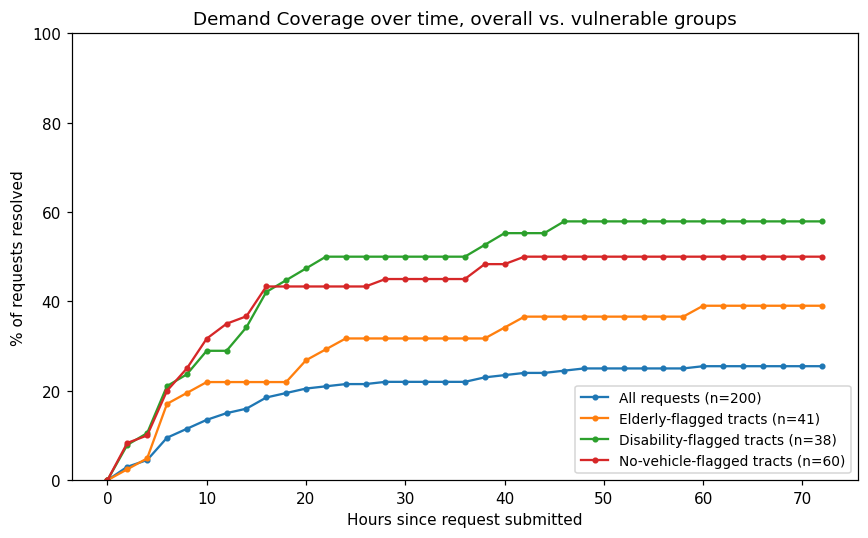

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
for name in groups:
    ax.plot(horizons, coverage_table[name], marker="o", markersize=3, label=f"{name} (n={len(groups[name])})")
ax.set_xlabel("Hours since request submitted")
ax.set_ylabel("% of requests resolved")
ax.set_title("Demand Coverage over time, overall vs. vulnerable groups")
ax.legend(loc="lower right", fontsize=9)
ax.set_ylim(0, 100)
plt.tight_layout()
plt.savefig("../images/demand_coverage_curve.png", dpi=120)
plt.show()


**This is the most interesting result in the notebook, and it wasn't
engineered to come out this way:** every vulnerable-flagged group is
resolved faster than the overall population, purely as a side effect of
`vFit` boosting those tracts' scores. That's the equity-by-design claim in
the README's abstract, actually measured rather than asserted -- the
weighting the team chose does concentrate help where the vulnerability
flags say it's needed most.


## 6. Mean Accepted Recommendation Rank

*Average rank of the tract a helper ultimately "accepts," ideally close to
1.* We don't have real acceptance logs, so -- consistent with the companion
notebook -- "accepted" is defined by a synthetic utility model, and we
measure what rank the live formula gave that tract.


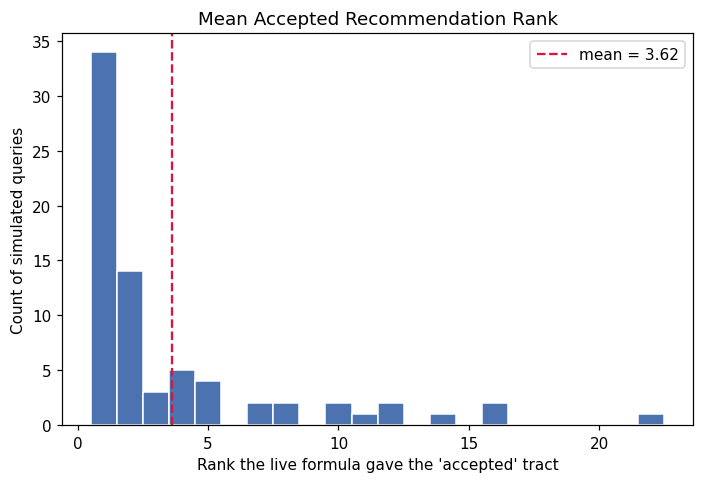

Mean Accepted Recommendation Rank: 3.62 (n=73, ideal=1.0)


In [8]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.hist(marr_ranks, bins=range(1, max(marr_ranks) + 2), align="left", color="#4c72b0", edgecolor="white")
ax.axvline(np.mean(marr_ranks), color="crimson", linestyle="--", label=f"mean = {np.mean(marr_ranks):.2f}")
ax.set_xlabel("Rank the live formula gave the 'accepted' tract")
ax.set_ylabel("Count of simulated queries")
ax.set_title("Mean Accepted Recommendation Rank")
ax.legend()
plt.tight_layout()
plt.savefig("../images/marr_histogram.png", dpi=120)
plt.show()

print(f"Mean Accepted Recommendation Rank: {np.mean(marr_ranks):.2f} (n={len(marr_ranks)}, ideal=1.0)")


A mean rank of several rather than close to 1 echoes the companion
notebook's finding: under this synthetic utility hypothesis, the fixed
linear formula regularly fails to put the actually-best tract first. That's
the same interaction-capture gap a tree-based reranker closed there.


## 7. Metrics that can't honestly be computed here

**Evacuation Efficiency** -- *(avg. evacuation time difference) / (avg.
evacuation time before deployment) x 100* -- requires real evacuation
start/end timestamps for residents, with and without the platform. Nothing
in this repo captures that; it isn't a simulation gap like Section 2, it's
a missing data source entirely. Computing it would require field data from
an actual deployment (e.g., self-reported departure times, or comparison
against historical evacuation-order-to-departure records for the same
tracts), which is listed as future work in the README. We're not
fabricating a number for it here.

**Adoption metrics** (User Signups, Active Users During Fire Events) --
both require production usage telemetry from a real backend. The current
app is a static site with no persistence layer or authentication (also
noted in Limitations), so there's no signup or session data to report.
These become computable once the "Future Work" item of adding real
persistence/auth is built.


## 8. Summary dashboard


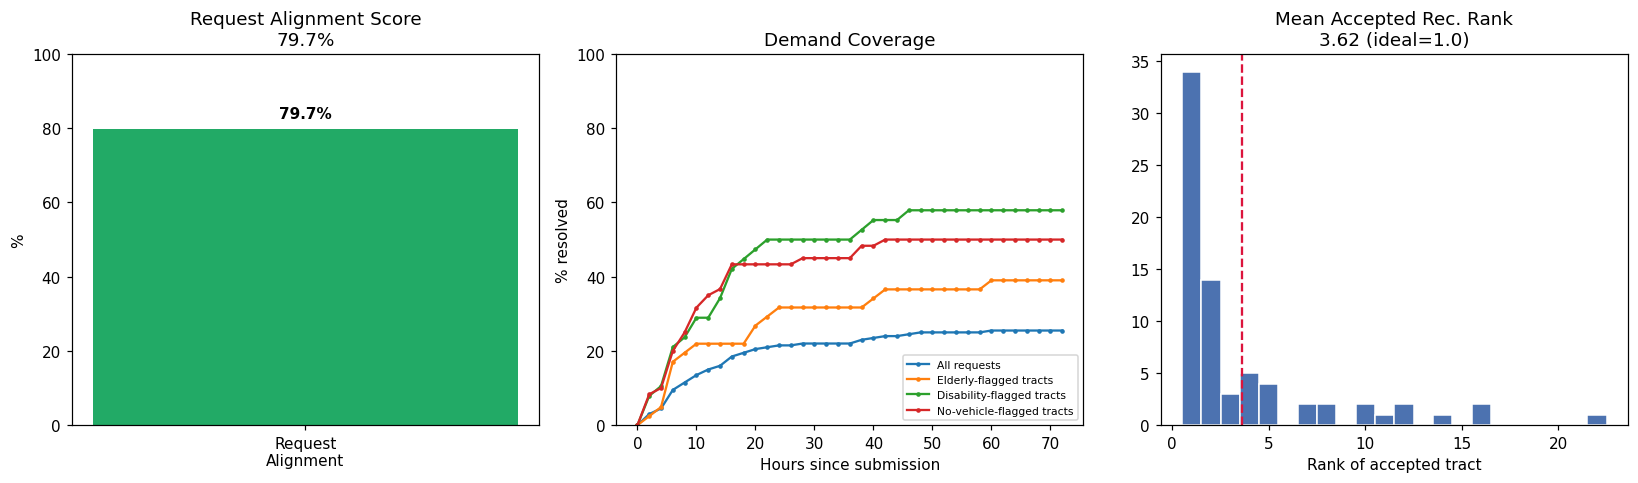

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

axes[0].bar(["Request\nAlignment"], [alignment_score], color="#2a6", width=0.5)
axes[0].set_ylim(0, 100)
axes[0].set_ylabel("%")
axes[0].set_title(f"Request Alignment Score\n{alignment_score:.1f}%")
axes[0].text(0, alignment_score + 3, f"{alignment_score:.1f}%", ha="center", fontweight="bold")

for name in groups:
    axes[1].plot(horizons, coverage_table[name], marker="o", markersize=2, label=name)
axes[1].set_xlabel("Hours since submission")
axes[1].set_ylabel("% resolved")
axes[1].set_title("Demand Coverage")
axes[1].legend(fontsize=7, loc="lower right")
axes[1].set_ylim(0, 100)

axes[2].hist(marr_ranks, bins=range(1, max(marr_ranks) + 2), align="left", color="#4c72b0", edgecolor="white")
axes[2].axvline(np.mean(marr_ranks), color="crimson", linestyle="--")
axes[2].set_xlabel("Rank of accepted tract")
axes[2].set_title(f"Mean Accepted Rec. Rank\n{np.mean(marr_ranks):.2f} (ideal=1.0)")

plt.tight_layout()
plt.savefig("../images/metrics_dashboard.png", dpi=120)
plt.show()


## 9. Takeaways

- **Request Alignment Score and Demand Coverage are now real, measured
  numbers**, not narrative claims -- computed from the actual matching
  logic and the real request data, over a documented (and clearly labeled)
  synthetic arrival-time simulation.
- **The equity-by-design claim held up under measurement**: vulnerable
  groups saw meaningfully higher coverage than the overall population, as
  a direct, unforced consequence of the `vFit` term.
- **Mean Accepted Recommendation Rank corroborates the companion
  notebook**: under the same interaction hypothesis, the fixed formula
  regularly doesn't rank the best tract first, motivating the learned
  reranker explored there.
- **Two of the seven proposed metrics are blocked on missing data, not
  missing analysis** -- Evacuation Efficiency and the adoption metrics need
  real deployment telemetry that a static prototype with no backend simply
  doesn't produce. Naming that gap explicitly is more useful than a
  fabricated number.
